<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_21_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import precision_score, recall_score

# Problem 1: Mall Customer Segmentation
### Dataset: Mall Customer Segmentation : https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

Questions:
- Why do you need to scale the features before applying K-Means?
- Use the Elbow method (K=1 to 10). What is the optimal number of clusters?
- Train K-Means with K=5. How many customers are in each cluster?
- What are the cluster center coordinates for K=5?
- Which cluster would you target for luxury products and why?


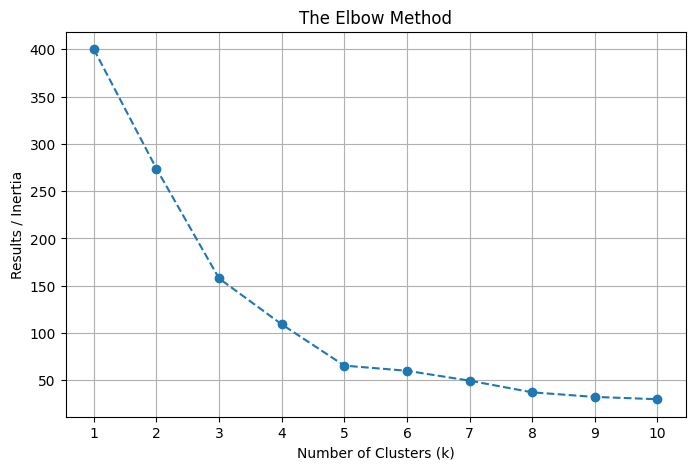


Cluster Center Coordinates: 
 [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]

Cluster Centers (original units):
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [2]:
# Why do you need to scale the features before applying K-Means?
# Ans: Because k-means is too sensitive to the features. So to ensure all the features contribute equally to the distance calculations,
# it is necessary to scale the features before applying k-means.

# Use the Elbow method (K=1 to 10). What is the optimal number of clusters?
df_mall = pd.read_csv('Mall_Customers.csv')

X = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

results = []
k_values = range(1, 11)

for k in k_values:
  kmeans = KMeans(n_clusters=k, init = 'k-means++', max_iter=400, random_state = 42)
  kmeans.fit(X_scaled)
  df_mall['clusters'] = kmeans.labels_

  results.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, results, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Results / Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()
print()

# What is the optimal number of clusters?
# Ans: Optimal number is 5

# Train K-Means with K=5. How many customers are in each cluster?
kmeans = KMeans(n_clusters=5, init = 'k-means++', max_iter = 400, random_state=42)
kmeans.fit(X_scaled)
df_mall['clusters'] = kmeans.labels_

# How many customers are in each cluster?
# Ans:
df_mall['clusters'].value_counts().sort_index()

# What are the cluster center coordinates for K=5?
centroids = kmeans.cluster_centers_
print('Cluster Center Coordinates: \n', centroids)

print()

centers_original = scaler.inverse_transform(centroids)
print('Cluster Centers (original units):\n', centers_original)

# Which cluster would you target for luxury products and why?
# Ans: the cluster with values 0.99158305 and 1.23950275 would be targeted for luxury products because it shows high income with high spending score.

# Problem 2: Iris Dataset Clustering
### Dataset: Iris Dataset: https://www.kaggle.com/datasets/uciml/iris

Questions:
- Scale the 4 features. Why is scaling necessary?
- Use the Elbow method and Silhouette Score to find optimal K. What is the best K?
- Train K-Means with K=3. How many samples in each cluster?
- Compare K-Means labels with actual species. Which cluster matches Setosa?


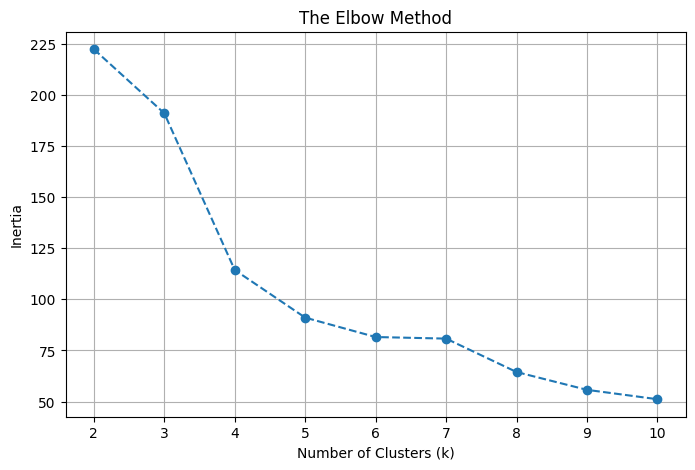

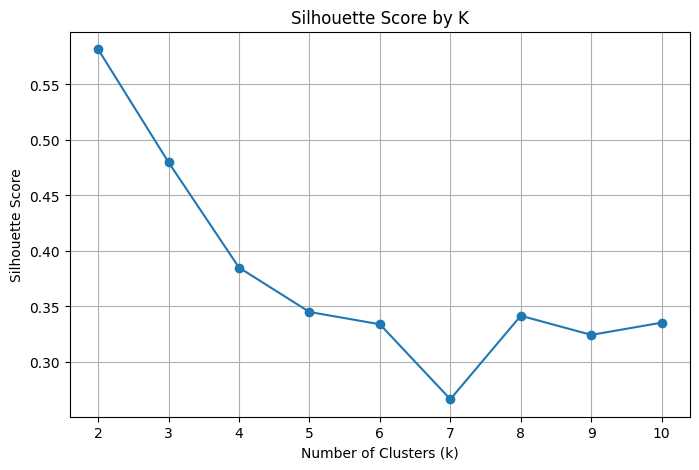


2 0.5817500491982808
3 0.4798814508199818
4 0.3850454053045392
5 0.34503345350274617
6 0.33394323040061763
7 0.2664290993719981
8 0.34162906041313373
9 0.3243991438983545
10 0.33540615043919825


target,0,1,2
Cluster,,,
0,0,46,50
1,33,0,0
2,17,4,0


In [3]:
# load dataset
df_iris = load_iris(as_frame=True).frame

# Scale the 4 features. Why is scaling necessary?
X = df_iris[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Why is scaling necessary?
# Ans: To ensure equal contribution of distance calc.

# Use the Elbow method and Silhouette Score to find optimal K. What is the best K?
results = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
  kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=400, random_state=42)
  pred = kmeans.fit_predict(X_scaled)
  results.append(kmeans.inertia_)
  sil_scores.append(silhouette_score(X_scaled, pred))

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, results, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print()

# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print()

for k, s in zip(k_values, sil_scores):
    print(k, s)

# What is the best K?
# Ans: Silhouette score is maximized at K=2 (0.58), but we choose K=3 since it matches
# the known 3 iris species (Setosa, Versicolor, Virginica). The drop from K=2 to K=3
# happens because Versicolor and Virginica overlap in feature space and aren't
# perfectly separable, while Setosa is distinct.

# Train K-Means with K=3. How many samples in each cluster?
kmeans_iris = KMeans(n_clusters=3, init='k-means++', max_iter=400, random_state=42)
kmeans_iris.fit(X_scaled)

df_iris['Cluster'] = kmeans_iris.labels_

# How many samples in each cluster?
df_iris['Cluster'].value_counts().sort_index()

# Compare K-Means labels with actual species. Which cluster matches Setosa?
pd.crosstab(df_iris['Cluster'], df_iris['target'])

# Problem 3: Credit Card Customer Segmentation
### Dataset: Credit Card Dataset: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

Questions:
- Which columns have missing values? How will you handle them?
- Use the Elbow method and Silhouette Score. What is the optimal K?
- Train K-Means with K=4. What are the cluster sizes?
- What are the average BALANCE, PURCHASES, CREDIT_LIMIT, and PAYMENTS for each cluster?
- Which cluster is most profitable for the bank? Which is risky?


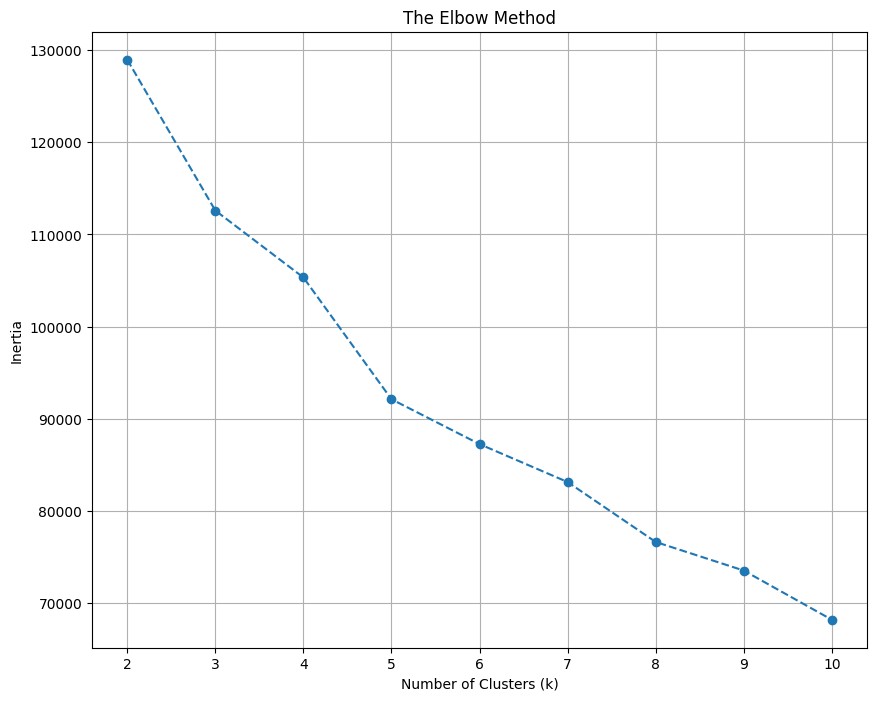

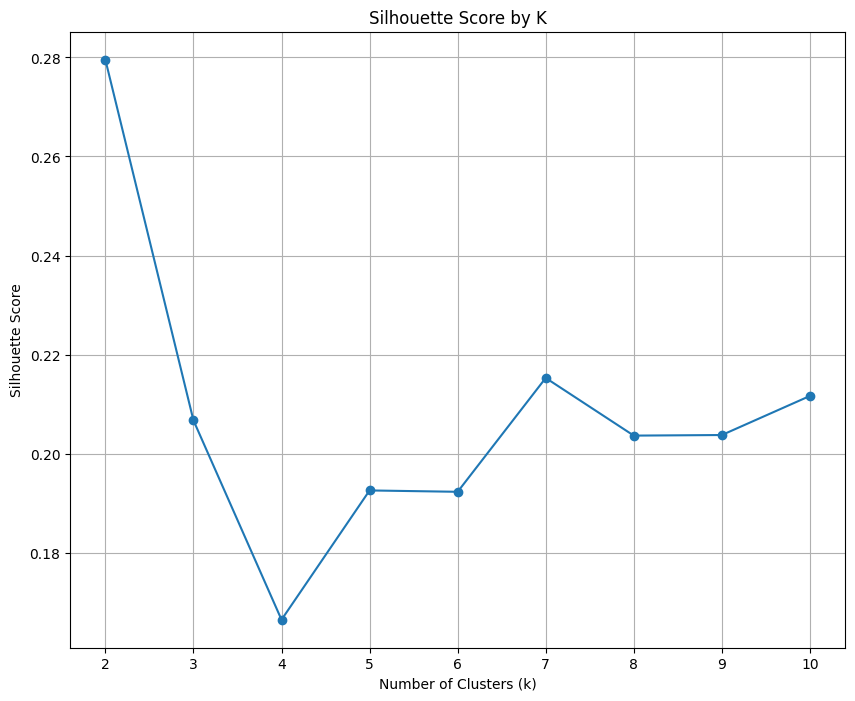


2 0.27953987242960154
3 0.20671817817880617
4 0.1664601900140412
5 0.19256596919095406
6 0.19229183109910575
7 0.21527906424041757
8 0.20363733953443425
9 0.20375590708205218
10 0.21164744068517044


,BALANCE,PURCHASES,CREDIT_LIMIT,PAYMENTS
Clusters,,,,
0,5010.394668,716.017789,8208.653578,4173.817878
1,108.430006,350.247868,3632.112008,1036.853064
2,1253.817942,2182.022178,5121.987288,2148.583305
3,1495.324927,283.482824,3216.349960,947.961448


In [16]:
# load dataset
df_card = pd.read_csv('CC GENERAL.csv')
df_card.isnull().sum()

# Which columns have missing values? How will you handle them?
# Ans: Column CREDIT_LIMIT has one missing value and the column MINIMUM_PAYMENTS has the most missing values.

# How will you handle them?
df_card['CREDIT_LIMIT'] = df_card['CREDIT_LIMIT'].fillna(df_card['CREDIT_LIMIT'].median())
df_card['MINIMUM_PAYMENTS'] = df_card['MINIMUM_PAYMENTS'].fillna(df_card['MINIMUM_PAYMENTS'].median())

X = df_card.drop('CUST_ID', axis = 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

result = []
sil_res = []
kvals = range(2, 11)

for k in kvals:
  kmeans = KMeans(n_clusters=k, init = 'k-means++', max_iter = 400, random_state = 42)
  pred = kmeans.fit_predict(X_scaled)

  result.append(kmeans.inertia_)

  sil_score = silhouette_score(X_scaled, pred)
  sil_res.append(sil_score)

plt.figure(figsize = (10, 8))
plt.plot(kvals, result, marker = 'o', linestyle = '--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print()

# Silhouette plot
plt.figure(figsize=(10, 8))
plt.plot(kvals, sil_res, marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print()

for k, s in zip(kvals, sil_res):
  print(k, s)

# What is the optimal K?
# Ans: Silhouette score is highest at K=2 (0.28). We still use K=4 for the segmentation task since it gives more useful, business-actionable customer groups, even though
# its silhouette score (0.166) is lower.

# Train K-Means with K=4. What are the cluster sizes?
kmeans_card = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 400, random_state = 42)
kmeans_card.fit(X_scaled)

df_card['Clusters'] = kmeans_card.labels_
df_card['Clusters'].value_counts().sort_index()

# What are the average BALANCE, PURCHASES, CREDIT_LIMIT, and PAYMENTS for each cluster?
df_card.groupby('Clusters')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']].mean()

# Which cluster is most profitable for the bank? Which is risky?
# Ans: The cluster 2 is most profitable because their purchase and payment history is well maintained despite of their balance.
# On the other hand the risky cluster is 0 because their payment history shows that they do not fulfill their debt despite of their high balance.

# Problem 4: Anomaly Detection with K-Means
### Dataset: Credit Card Fraud Detection: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Questions:
- What is the fraud percentage in this dataset?
- Train K-Means with K=10. For each point, calculate distance to nearest cluster center.
- Set a threshold at the 95th percentile of distances. How many frauds are detected?
- What is the precision and recall for fraud detection using this method?
- What are the limitations of using K-Means for anomaly detection?


In [24]:
# load dataset
df_fraud = pd.read_csv('creditcard.csv')

# What is the fraud percentage in this dataset?
fraud_count = df_fraud['Class'].value_counts()
fraud_percent = (df_fraud['Class'].sum() / len(df_fraud)) * 100
print(f"Fraud percentage: {fraud_percent:.4f}%")

X = df_fraud.drop('Class', axis = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K-Means with K=10. For each point, calculate distance to nearest cluster center.
kmeans_fraud = KMeans(n_clusters = 10, init = 'k-means++', max_iter = 400, random_state = 42)
kmeans_fraud.fit(X_scaled)

df_fraud['Clusters'] = kmeans_fraud.labels_
df_fraud['Clusters'].value_counts().sort_index()

distances = kmeans_fraud.transform(X_scaled).min(axis=1)
df_fraud['distance'] = distances

# Set a threshold at the 95th percentile of distances. How many frauds are detected?
threshold = np.percentile(distances, 95)
print(f"Threshold (95th percentile): {round(threshold, 2)}")

df_fraud['predicted_anomaly'] = (df_fraud['distance'] > threshold).astype(int)

detected_frauds = ((df_fraud['predicted_anomaly'] == 1) & (df_fraud['Class'] == 1)).sum()
print(f"Frauds detected: {detected_frauds} out of {df_fraud['Class'].sum()}")

# What is the precision and recall for fraud detection using this method?
precision = precision_score(df_fraud['Class'], df_fraud['predicted_anomaly'])
recall = recall_score(df_fraud['Class'], df_fraud['predicted_anomaly'])
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")

# What are the limitations of using K-Means for anomaly detection?
# Ans: it requires a predefined number of clusters (k), fails on non-spherical shapes,
# and is highly vulnerable to outliers, which can skew the centroids. Additionally,
# it struggles with varying data densities and often results in high false-positive rates

Fraud percentage: 0.1727%
Threshold (95th percentile): 6.79
Frauds detected: 417 out of 492
Precision: 0.0293, Recall: 0.8476
